# Interpretation using CAM method

Interpretation of classifier output and creation of heatmaps using CAM (Class Activation Map).
The CAM method was introduced by Bolei Zhou _et al._ in _Learning Deep Features for Discriminative Localization_, [arXiv:1512.04150 [cs.CV]](https://arxiv.org/abs/1512.04150) (2015).

## Configuration

Imports

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torchvision import datasets
import torchvision.transforms.v2 as transforms

We use previously created classifier trained on CIFAR10.

In [2]:
from tiny_net import create_model

Configuration

In [3]:
DATA_DIR = './data'
MODELS_DIR = './models'

IMAGE_SIZE = 32
NUM_CLASSES = 10

In [4]:
DEVICE = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
print("device:", DEVICE)

device: cuda


## CAM

In [5]:
class Hook():
    def hook_func(self, module, args, output):
        self.output = output.detach().clone()

In [6]:
def forward_cam(model, x):
    hook = Hook()    
    hook_handle = model[-1][3].register_forward_hook(hook.hook_func)
    out = model(x)
    hook_handle.remove()

    act = hook.output
    linear_weight = model[-1][-1].weight
    hw = act.shape[-2:]
    cam_map = torch.matmul(linear_weight, act.flatten(-2)).unflatten(-1, hw)
    return out, cam_map

## Data

In [7]:
test_transform = transforms.Compose([
    transforms.ToImage(),
    transforms.ToDtype(torch.float, scale=True),
])

In [8]:
test_dset = datasets.CIFAR10(root=DATA_DIR, train=False, download=True, transform=test_transform)

In [9]:
def dataset_show_image(dset, idx):
    X, Y = dset[idx]
    fig = plt.figure()
    ax = fig.add_subplot(111)
    ax.set_axis_off()
    ax.imshow(np.moveaxis(X.numpy(), 0, -1))
    ax.set_title(dset.classes[Y])
    plt.show()

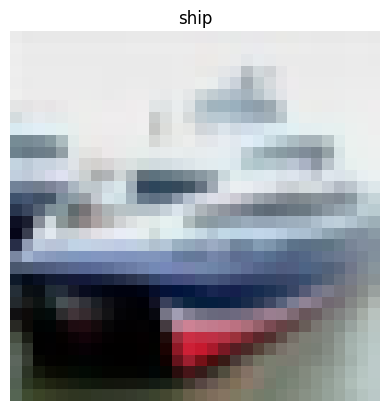

In [10]:
dataset_show_image(test_dset, 1)

## Model

In [11]:
model = create_model(DEVICE)

In [12]:
print("Number of parameters: {:,}".format(sum(p.numel() for p in model.parameters())))

Number of parameters: 79,597


In [13]:
model.load_state_dict(torch.load(os.path.join(MODELS_DIR, 'residual_tiny.pt')))

<All keys matched successfully>

In [14]:
model.eval();

## Examples

In [15]:
def plot_image_heatmap(ax, image, cam, name, alpha=0.6):
    ax.set_axis_off()
    ax.imshow(np.moveaxis(image.numpy(), 0, -1))
    ax.imshow(cam, alpha=alpha,
              extent=(0, image.size(2), image.size(1), 0),
              interpolation='bilinear', cmap='magma');
    ax.set_title(name)

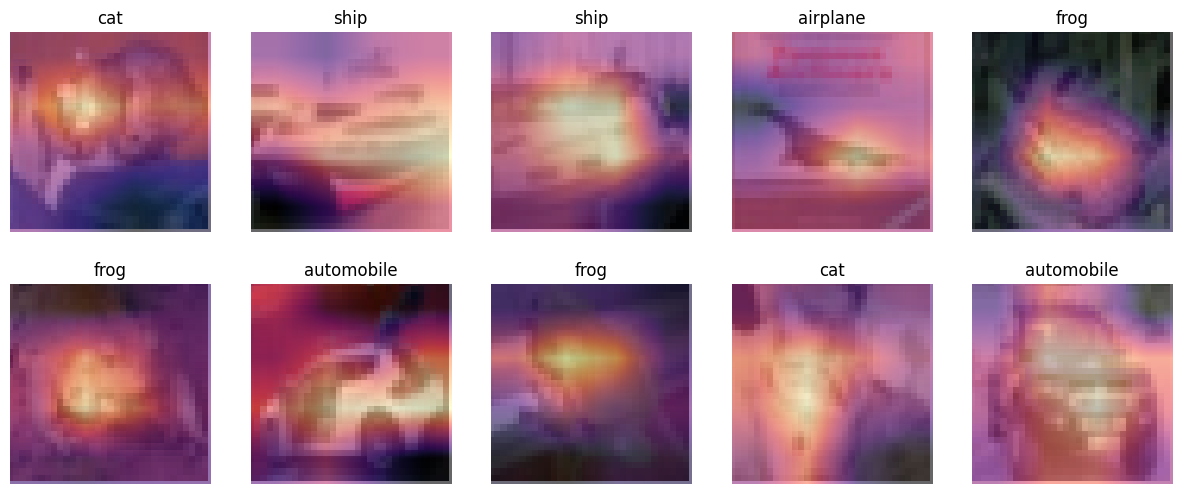

In [16]:
fig = plt.figure(figsize=(15, 6))

for idx in range(10):
    image, label = test_dset[idx]
    
    with torch.inference_mode():
        logits, cam_map = forward_cam(model, image.unsqueeze(0).to(DEVICE))
    cam_map = cam_map.squeeze(0).cpu().numpy()

    ax = fig.add_subplot(2, 5, idx + 1)
    plot_image_heatmap(ax, image, cam_map[label], test_dset.classes[label])

fig.show()